In [1]:
import numpy as np
from scipy import optimize
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib.axes as axe
import pandas as pd
import datetime as dt
import gurobipy as gp
from gurobipy import GRB
import cvxpy as cp
import yaml

import random
from itertools import chain, combinations, product
import time

import glob
import os

plt.rcParams['text.usetex'] = True

# Functions

In [2]:
# def poly(alpha, x, p=4):
#     assert alpha.shape[0] == p+1,  "alpha should be a length-(p+1) vector."
#     assert np.all(alpha > 0.0), "All entries of alpha should be strictly positive."
#     assert x >= 0.0, "x should be non-negative."
    
#     return sum(alpha[k] * (x**k) for k in range(p))

# def poly_simplified(alpha, x, p=4):
#     assert alpha.shape[0] == p+1,  "alpha should be a length-(p+1) vector."
#     assert np.all(alpha > 0.0), "All entries of alpha should be strictly positive."
#     assert x >= 0.0, "x should be non-negative."
    
#     return alpha[0] + alpha[p-1] * (x**(p-1))

# def route_latency(alphas, xs, edges, p=4):
#     assert len(alphas.shape) == 2, "alphas should be a 2D array."
#     assert alphas.shape[0] == xs.shape[0], "The first dimension of alphas should equal the dimension of xs."
#     assert set(edges).issubset(range(alphas.shape[0])), "edges should be a subset of indices of edges"
    
#     return sum([poly(alphas[e, :], xs[e], p=4) for e in edges])


In [3]:
def reshape_vec(v):

    # print("length of v to reshape:", v.shape[0])

    len_v = v.shape[0]
    v_reshaped = v.reshape((len_v, 1))
    
    return v_reshaped


In [4]:
# DR: distributionally robust

def generate_R_from_edge_node_matrix(edge_node_matrix):
    assert len(edge_node_matrix.shape) == 2
    assert edge_node_matrix.shape[1] == 2
    
    num_edges = edge_node_matrix.shape[0]
    num_nodes = np.max(edge_node_matrix) + 1
    
    R = np.zeros((num_nodes - 1, num_edges))
    
    for node_index in range(R.shape[0]):
        for edge_index in range(R.shape[1]):
            if edge_node_matrix[edge_index][0] == node_index:
                R[node_index, edge_index] = 1
            elif edge_node_matrix[edge_index][1] == node_index:
                R[node_index, edge_index] = -1

    return R


def generate_Gamma(B, R):

    inv_B = np.linalg.inv(B)
    R_inv_B_R_top = np.linalg.inv(R @ inv_B @ R.T)
    
    return inv_B - inv_B @ R.T @ R_inv_B_R_top @ R @ inv_B


def compute_eps_max(Gamma, B, R, alpha_mean_nominal, eta, delta):
    
    # print()
    # print("Gamma.shape", Gamma.shape)
    # print("alpha_mean_nominal.shape:", alpha_mean_nominal.shape)
    # print()
    
    num_nodes = R.shape[0] + 1
    num_edges = R.shape[1]
    Gamma_norm = np.linalg.norm(Gamma, ord=2)
    inv_B = np.linalg.inv(B)
    R_inv_B_R_top = np.linalg.inv(R @ inv_B @ R.T)
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))
    offset_with_eta = inv_B @ R.T @ R_inv_B_R_top @ eta_vec

    # Define and solve the CVXPY problem.
    eps = cp.Variable(1)
    tau = cp.Variable(num_edges)
    func = eps
    obj = cp.Maximize(func)
    constr = [Gamma @ tau <= - Gamma_norm * (eps + delta) * np.ones(num_edges) \
                 - Gamma @ alpha_mean_nominal + offset_with_eta]
    constr += [tau >= 0.0]
    constr += [eps >= 0.0]
    prob = cp.Problem(obj, constr)
    prob.solve()

    # # Print result.
    # print()
    # print("eps_max:", eps.value[0])
    # print()

    return eps.value
    

def compute_opt_DR_toll_constrained(Gamma, B, R, alpha_mean_nominal, eta, eps, delta):
    
    num_nodes = R.shape[0] + 1
    num_edges = R.shape[1]
    Gamma_norm = np.linalg.norm(Gamma, ord=2)
    inv_B = np.linalg.inv(B)
    R_inv_B_R_top = np.linalg.inv(R @ inv_B @ R.T)
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))
    offset_with_eta = inv_B @ R.T @ R_inv_B_R_top @ eta_vec
    
    tau = cp.Variable(num_edges)
    func = eps * cp.norm(Gamma @ tau + offset_with_eta) \
            + cp.quad_form(tau, Gamma) + alpha_mean_nominal.T @ Gamma @ tau
#     func = cp.quad_form(tau, Gamma) + alpha_mean_nominal.T @ Gamma @ tau
    obj = cp.Minimize(func)
    constr = [Gamma @ tau <= - Gamma_norm * (eps + delta) * np.ones(num_edges) \
                 - Gamma @ alpha_mean_nominal + offset_with_eta]
    constr += [tau >= 0.0]
    
    prob = cp.Problem(obj, constr)
    prob.solve()

    # # Print result.
    # print()
    # print("DR optimal toll:", tau.value)
    # print()
    # print("Worst-case DR latency:", prob.value)
    # print()
    
    return tau.value, prob.value

def compute_opt_DR_toll(Gamma, B, R, alpha_mean_nominal, eta, eps, delta):
    
    num_nodes = R.shape[0] + 1
    num_edges = R.shape[1]
    Gamma_norm = np.linalg.norm(Gamma, ord=2)
    inv_B = np.linalg.inv(B)
    R_inv_B_R_top = np.linalg.inv(R @ inv_B @ R.T)
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))
    offset_with_eta = inv_B @ R.T @ R_inv_B_R_top @ eta_vec
    
    tau = cp.Variable(num_edges)
    func = eps * cp.norm(Gamma @ tau + offset_with_eta) \
            + cp.quad_form(tau, Gamma) + alpha_mean_nominal.T @ Gamma @ tau
#     func = cp.quad_form(tau, Gamma) + alpha_mean_nominal.T @ Gamma @ tau
    obj = cp.Minimize(func)
    # constr = [Gamma @ tau <= - Gamma_norm * (eps + delta) * np.ones(num_edges) \
    #              - Gamma @ alpha_mean_nominal + offset_with_eta]
    constr = []
    constr += [tau >= 0.0]
    
    prob = cp.Problem(obj, constr)
    prob.solve()

    # # Print result.
    # print()
    # print("DR optimal toll:", tau.value)
    # print()
    # print("Worst-case DR latency:", prob.value)
    # print()
    
    return tau.value, prob.value


def latency_eq_worst(B, R, alpha, tau, eta):
    num_nodes = R.shape[0] + 1
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))
    
    tau = reshape_vec(tau)
    alpha = reshape_vec(alpha)
    eta_vec = reshape_vec(eta_vec)
    
    BRR_matrix = np.block([[B, R.T], [R, np.zeros((num_nodes-1, num_nodes-1))]])

    return np.block([tau.T, eta_vec.T]) @ np.linalg.inv(BRR_matrix) @ np.block([[alpha + tau], [- eta_vec]])

    
def compute_worst_theta(B, R, tau, eta, alpha_mean_nominal, eps):

    num_nodes = R.shape[0] + 1
    num_edges = R.shape[1]
    
    BRR_matrix = np.block([[B, R.T], [R, np.zeros((num_nodes-1, num_nodes-1))]])
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))

    # print("tau.shape:", tau.shape)
    # print("eta_vec.shape", eta_vec.shape)
    
    tau_eta = np.append(tau, eta_vec)

    # print("np.block([np.identity(num_edges), np.zeros((num_nodes-1, num_edges))]).shape:", \
    #      np.block([np.identity(num_edges), np.zeros((num_nodes-1, num_edges))]).shape)
    # print("BRR_matrix.shape:", BRR_matrix.shape)
    # print("eta_vec.shape", eta_vec.shape)
    
    q_tau = np.block([np.identity(num_edges), np.zeros((num_edges, num_nodes-1))]) @ np.linalg.inv(BRR_matrix) @ tau_eta
    
    theta_worst = alpha_mean_nominal + eps * q_tau / np.linalg.norm(q_tau)
    
    return theta_worst

def sample_from_ball(center, radius, n_samples=1):
    center = np.asarray(center)
    d = center.shape[0]
    
    # Step 1: random directions
    x = np.random.normal(size=(n_samples, d))
    x /= np.linalg.norm(x, axis=1, keepdims=True)
    
    # Step 2: radii
    u = np.random.uniform(0, 1, size=(n_samples, 1))
    r = radius * (u ** (1.0 / d))
    
    # Step 3: combine
    samples = center + r * x
    
    return samples

def latency_eq_worst_under_distribution_shift(B, R, alpha_mean_nominal, tau, eta, eps):

    num_nodes = R.shape[0] + 1
    eta_vec = eta * np.concatenate(([1], np.zeros(num_nodes-2)))
    
    tau = reshape_vec(tau)
    alpha_mean_nominal = reshape_vec(alpha_mean_nominal)
    eta_vec = reshape_vec(eta_vec)

    Gamma = generate_Gamma(B, R)
    B_inv = np.linalg.inv(B)
    R_B_inv_R_T = R @ B_inv @ R.T

    vec_temp = Gamma @ tau + B_inv @ R.T @ np.linalg.inv(R_B_inv_R_T) @ eta_vec

    return eps * np.linalg.norm(vec_temp) + tau.T @ Gamma @ tau + alpha_mean_nominal.T @ Gamma @ tau
    


In [5]:
# # a = np.array([1, 2, 3]).reshape((3, 1))
# # b = np.array([4, 5]).reshape((2, 1))

# a = np.array([1, 2, 3])
# b = np.array([4, 5])

# # np.block([[a], [b]])
# np.block([a, b])

# np.append([1, 2, 3], [2, 4])
# np.identity(3)
# np.block([np.identity(2), np.identity(2)])

# <font color='red'> Pigou Network

In [6]:
num_nodes = 1
num_edges = 2

In [9]:
beta = [1.5, 0.1]
B = np.diag(beta)
edge_node_matrix = np.array([[0, 1], [0, 1]])

alpha_mean_nominal = np.array([20.0, 30.0])

delta = 0.2
eta = 100.0

R = generate_R_from_edge_node_matrix(edge_node_matrix)
Gamma = generate_Gamma(B, R)
eps_max_original = compute_eps_max(Gamma, B, R, alpha_mean_nominal, eta, delta)[0]
eps_max_adjusted = max(min(eps_max_original, min(alpha_mean_nominal) - delta), 0.0)

print("eps_max_adjusted:", eps_max_adjusted)
print("eps_max_original:", eps_max_original)

# # Compute distributionally robust toll and corresponding worst-case latency (in theory):

# eps = 0.5 * eps_max_adjusted
# tau_opt, worst_case_ = compute_opt_DR_toll_constrained(Gamma, B, R, alpha_mean_nominal, eta, eps, delta)

# # Compute certainty equivalence toll and corresponding worst-case latency (in theory):



eps_max_adjusted: 19.8
eps_max_original: 39.8


In [10]:
print(cp.installed_solvers())

['CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'GUROBI', 'MOSEK', 'OSQP', 'SCIPY', 'SCS']


## Main Code:

In [14]:
num_eps = 5
# eps_set = np.linspace(0.0, eps_max_adjusted, num = num_eps)
eps_set = np.linspace(0.0, eps_max_original, num = num_eps)
num_samples = 10000

latency_array_full = np.zeros((eps_set.shape[0], eps_set.shape[0], num_samples))

worst_latency_array = np.zeros((num_eps, num_eps))
tau_array = np.zeros((num_eps, num_edges))
alpha_mean_array = np.zeros((num_eps, num_eps, num_edges))

# for eps_true, eps_hat in product(eps_set, repeat=2):
#     print(eps_true, eps_hat)

for i, eps_true in enumerate(eps_set):
    for j, eps_hat in enumerate(eps_set):
#         tau_eps_hat, _ = compute_opt_DR_toll_constrained(Gamma = Gamma,\
#                                              B = B,\
#                                              R = R,\
#                                              alpha_mean_nominal = alpha_mean_nominal,\
#                                              eta = eta,\
#                                              eps = eps_hat, \
#                                              delta = delta)

        tau_eps_hat, _ = compute_opt_DR_toll(Gamma = Gamma,\
                                     B = B,\
                                     R = R,\
                                     alpha_mean_nominal = alpha_mean_nominal,\
                                     eta = eta,\
                                     eps = eps_hat, \
                                     delta = delta)
        tau_array[j, :] = tau_eps_hat
        
        # print("tau_eps_hat:", tau_eps_hat)
        alpha_mean_eps = compute_worst_theta(B = B,\
                                             R = R,\
                                             tau = tau_eps_hat,\
                                             eta = eta,\
                                             alpha_mean_nominal = alpha_mean_nominal,\
                                             eps = eps_true)
        alpha_mean_array[i, j, :] = alpha_mean_eps
        alpha_vals = sample_from_ball(alpha_mean_eps, delta, n_samples = num_samples).T
        

        latency_array_temp = np.zeros(num_samples)
        for n in range(num_samples):
            latency_array_temp[n] = latency_eq_worst(B,\
                                                     R,\
                                                     alpha_vals[:, n],\
                                                     tau_eps_hat,\
                                                     eta)
        worst_latency_array[i, j] = np.mean(latency_array_temp)
        
        latency_array_full[i, j, :] = latency_array_temp
        
        # worst_latency_array[i, j] = s
        # break


# def compute_opt_DR_toll(Gamma, B, R, alpha_mean_nominal, eta, eps, delta):
# def compute_worst_theta(B, R, tau, eta, alpha_mean_nominal, eps):
# def latency_eq_worst(B, R, alpha, tau, eta):


## <font color='red'> To Do Above: Edit code to print distributions

## <font color='red'> Below: Code for Printing Out Data in Paper

In [15]:
## Data in the paper:

# print("alpha_vals.shape:", alpha_vals.shape)
# worst_latency_array
worst_latency_array[:-1, :-1]
# eps_set

array([[3859.27449972, 3870.66789667, 3900.9333893 , 3945.14422401],
       [4765.85523103, 4754.07197317, 4763.99234138, 4790.45209229],
       [5672.40118982, 5637.53176081, 5627.04815927, 5635.68579627],
       [6578.91230508, 6520.88890752, 6490.26132952, 6481.11591666]])

In [16]:
latency_array_trunc = latency_array_full[:-1, :-1, :]
latency_array_trunc.shape

(4, 4, 10000)

In [21]:
# Blue: No consideration of distributional robustness (baseline)
# Orange: Considers distributional robustness

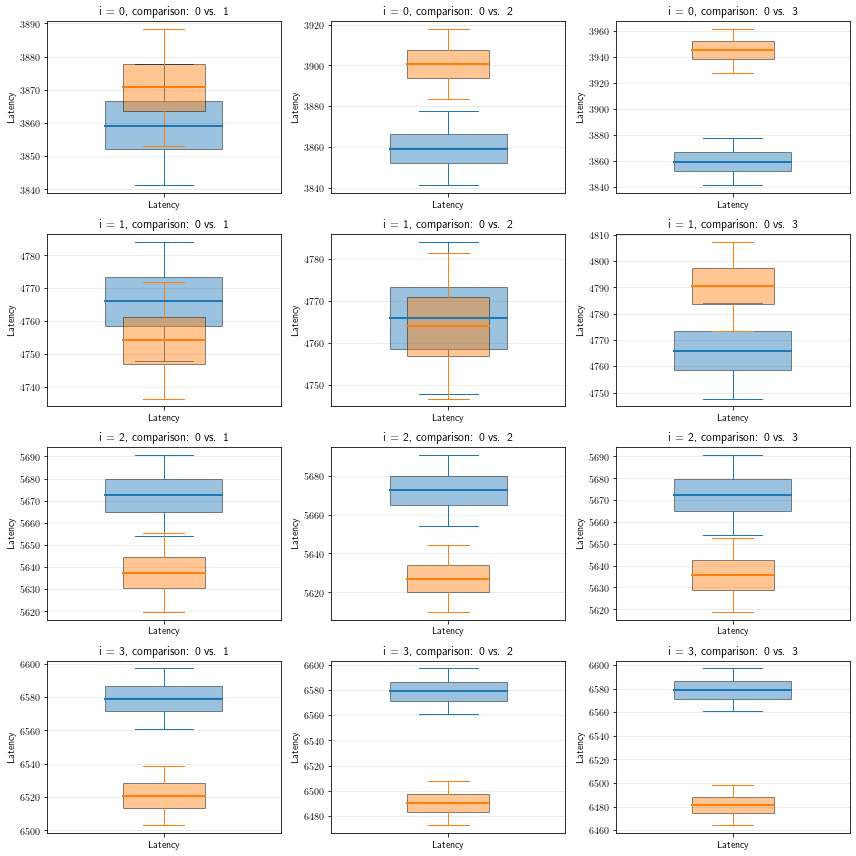

In [17]:
fig = plt.figure(figsize=(12, 12))

for i in range(4):
    for j in range(3):
        plt.subplot(4, 3, 3 * i + j + 1)

        # Reference distribution: latency_array_trunc[i, 0, :]
        plt.boxplot(
            latency_array_trunc[i, 0, :],
            positions=[1],
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor="tab:blue", alpha=0.45),
            medianprops=dict(color="tab:blue", linewidth=2),
            whiskerprops=dict(color="tab:blue"),
            capprops=dict(color="tab:blue"),
            flierprops=dict(
                marker="o",
                markerfacecolor="tab:blue",
                markeredgecolor="tab:blue",
                alpha=0.25,
                markersize=3,
            ),
        )

        # Comparison distribution: latency_array_trunc[i, j + 1, :]
        plt.boxplot(
            latency_array_trunc[i, j + 1, :],
            positions=[1],
            widths=0.35,
            patch_artist=True,
            boxprops=dict(facecolor="tab:orange", alpha=0.45),
            medianprops=dict(color="tab:orange", linewidth=2),
            whiskerprops=dict(color="tab:orange"),
            capprops=dict(color="tab:orange"),
            flierprops=dict(
                marker="o",
                markerfacecolor="tab:orange",
                markeredgecolor="tab:orange",
                alpha=0.25,
                markersize=3,
            ),
        )

        plt.title(f"i = {i}, comparison: 0 vs. {j + 1}")
        plt.xticks([1], ["Latency"])
        plt.ylabel("Latency")
        plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

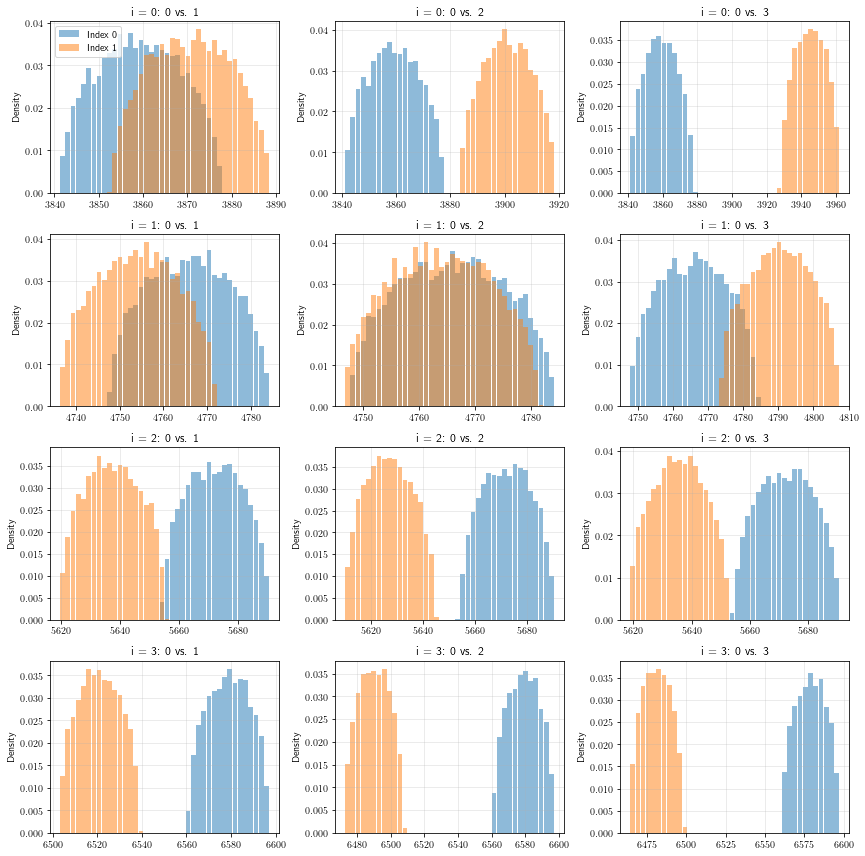

In [20]:

fig = plt.figure(figsize=(12, 12))

num_bins = 40

for i in range(4):
    for j in range(3):
        plt.subplot(4, 3, 3*i + j + 1)

        x1 = latency_array_trunc[i, 0, :]
        x2 = latency_array_trunc[i, j+1, :]

        # Use common bins so the histograms are directly comparable
        bins = np.linspace(
            min(x1.min(), x2.min()),
            max(x1.max(), x2.max()),
            num_bins + 1
        )

        counts1, edges = np.histogram(x1, bins=bins, density=True)
        counts2, _ = np.histogram(x2, bins=bins, density=True)

        centers = 0.5 * (edges[:-1] + edges[1:])
        width = 0.9 * (edges[1] - edges[0])

        plt.bar(
            centers,
            counts1,
            width=width,
            alpha=0.5,
            color="tab:blue",
            label="Index 0",
            align="center",
        )

        plt.bar(
            centers,
            counts2,
            width=width,
            alpha=0.5,
            color="tab:orange",
            label=f"Index {j+1}",
            align="center",
        )

        plt.title(f"i = {i}: 0 vs. {j+1}")
        plt.ylabel("Density")
        plt.grid(alpha=0.3)

        if i == 0 and j == 0:
            plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
tau_array
# tau_array_gap_list = [np.mean(tau_array[eps_id_1, :] - tau_array[eps_id_2, :]) \
#                           for eps_id_1 in range(num_eps-1) for eps_id_2 in range(1, num_eps)]
# tau_array_gap_list

In [ ]:
for i, eps_true in enumerate(eps_set):
    for j, eps_hat in enumerate(eps_set):
        print(alpha_mean_array[i, j, :])

In [ ]:
for i, eps_true in enumerate(eps_set):
    for j, eps_hat in enumerate(eps_set):
        print("eps_true, eps_hat:", eps_true, ",", eps_hat)
        
        tau_temp = tau_array[j, :]
        alpha_temp = alpha_mean_array[i, j, :]
        eta_vec = eta
        
        BR_block_inv = np.linalg.inv(np.block([[B, R.T], [R, 0]]))
        identity_zero_block = np.block([np.identity(2), np.zeros((2, 1))])
        vec_at_right = np.concatenate([-alpha_temp - tau_temp, [eta]])
        
        flow_Nash_expression = identity_zero_block @ BR_block_inv @ vec_at_right
        print(flow_Nash_expression)
        print()
        

In [ ]:
np.concatenate([[1, 2, 3], [4, 5]])

In [ ]:
worst_latency_array_from_observations = np.zeros((num_eps, num_eps))

for i, eps_true in enumerate(eps_set):
    for j, eps_hat in enumerate(eps_set):
        
        print("eps_true:", eps_true)
        print("eps_hat:", eps_hat)
        
        worst_latency_array_from_observations[i, j] = \
            latency_eq_worst_under_distribution_shift(B = B,\
                                                      R = R,\
                                                      alpha_mean_nominal = alpha_mean_nominal,\
                                                      tau = tau_array[j],\
                                                      eta = eta,
                                                      eps = eps_true)

# def latency_eq_worst_under_distribution_shift(B, R, alpha_mean_nominal, tau, eta, eps):

In [ ]:
worst_latency_array_from_observations

# <font color='red'> Red topic

# Scratch Work

In [ ]:
# Generate a random non-trivial linear program.
m = 15
n = 10
np.random.seed(1)
s0 = np.random.randn(m)
lamb0 = np.maximum(-s0, 0)
s0 = np.maximum(s0, 0)
x0 = np.random.randn(n)
A = np.random.randn(m, n)
b = A @ x0 + s0
c = -A.T @ lamb0

# Define and solve the CVXPY problem.
x = cp.Variable(n)
obj = cp.Minimize(c.T@x)
constr = [A @ x <= b]
prob = cp.Problem(obj, constr)
prob.solve()

# Print result.
print("\nThe optimal value is", prob.value)
print("A solution x is")
print(x.value)
print("A dual solution is")
print(prob.constraints[0].dual_value)

